# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-10: HR RhythmMamba Training (screening pass)

### What this notebook does
Trains RhythmMamba (state-space / Mamba, Zou & Guo et al., AAAI 2025) on the three preprocessed datasets (MCD + UBFC-rPPG + DLCN) as the third architecture in the screen-then-tune plan. Same pipeline as NB_P3_08/09: committed loader with multi-clip sampling, subject-wise split, temporal-rescale + hflip augmentation, cardiac_sqi soft-weighting, neg-Pearson + frequency loss, and the honest per-dataset / resting / Bland-Altman evaluation. Result compared against PhysNet (val HR MAE 8.07) and PhysFormer.

### RhythmMamba notes
- Repo: github.com/zizheng-guo/RhythmMamba (AAAI 2025), built on the rPPG-Toolbox framework (frame stem -> multi-temporal Mamba -> frequency-domain feed-forward -> rPPG head). Lightweight, linear-complexity, efficient (a good fit for free Kaggle GPU and the future long-window RR head).
- Hyperparameters: paper defaults live in the repo YAML; here we use sane rPPG-Toolbox defaults (Adam, lr 1e-3, cosine, 30 epochs) - these are the tuning knobs for later.
- Loss: reuse our neg-Pearson + frequency-match (SQI-weighted) to keep the screen comparable across architectures.

### Implementation risks (read before running)
1. **mamba-ssm / causal-conv1d** compile CUDA kernels - Section 1 installs them and may take several minutes; if it fails on this Kaggle image, we pivot to TYrPPG/Mambaout (which avoids the SSM dependency).
2. The model class + input orientation are auto-handled with fallbacks, but the **Section 5 sanity cell is the gate** - if it errors, paste the printed repo listing + error and it will be fixed. No frames are rendered.

## 1. Imports & Config (+ clone RhythmMamba, install mamba-ssm)

In [1]:
import os, sys, time, random, glob, importlib
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# Clone RhythmMamba and expose it on the path.
# Pinned to a specific commit so this notebook stays reproducible. The SHA was
# captured 2026-08-29 and may differ from the commit used in the original run,
# which was not recorded. The resolved SHA is printed into this cell's output.
REPO_URL = 'https://github.com/zizheng-guo/RhythmMamba'
REPO_SHA = '1533ad21cb4ae0d31e9dbb9afb0b1eefbed54aed'
if not os.path.exists('RhythmMamba'):
    os.system('git init -q RhythmMamba && git -C RhythmMamba remote add origin ' + REPO_URL)
    os.system('git -C RhythmMamba fetch -q --depth 1 origin ' + REPO_SHA)
    os.system('git -C RhythmMamba checkout -q FETCH_HEAD')
print('RhythmMamba commit:', os.popen('git -C RhythmMamba rev-parse HEAD').read().strip())
sys.path.append('RhythmMamba')
for d in glob.glob('RhythmMamba/**/', recursive=True):
    sys.path.append(d)

# Mamba deps (compile CUDA kernels - may take several minutes).
os.system('pip install einops -q')
os.system('pip install causal-conv1d --no-build-isolation -q')
os.system('pip install mamba-ssm --no-build-isolation -q')
try:
    import mamba_ssm
    print('mamba-ssm OK:', mamba_ssm.__version__ if hasattr(mamba_ssm, '__version__') else 'imported')
except Exception as e:
    print('WARNING mamba-ssm import failed:', repr(e))
    print('-> if this persists, we pivot to TYrPPG/Mambaout (no SSM dependency).')

DATA_DIR = Path('/kaggle/input/datasets/cezarytubacki/phase3-hr-train-dataset')

# Auto-discover H5 files in the dataset
H5_FILES = sorted([f.name for f in DATA_DIR.glob('*.h5')])

CLIP_LEN = 160
IMG_SIZE = 72
BATCH_SIZE = 8 # RhythmMamba is light; drop if OOM, raise if headroom
CLIPS_PER_REC = 2
NUM_WORKERS = 2
VAL_FRAC = 0.2
SEED = 42

AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_FLOOR = 0.05

LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 30
LAMBDA_FREQ = 0.2
HR_LOW, HR_HIGH = 0.66, 3.0

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
print('device:', device, '| DATA_DIR:', DATA_DIR)
print('files present:', [fn for fn in H5_FILES if (DATA_DIR / fn).exists()])

Cloning into 'RhythmMamba'...
Updating files: 100% (171/171), done.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.4/358.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.7/767.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 17.7 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


mamba-ssm OK: 2.3.2.post1
device: cuda | DATA_DIR: /kaggle/input/datasets/cezarytubacki/phase3-hr-train-dataset
files present: ['dlcn_phase3.h5', 'mcd_phase3.h5', 'ubfc_rppg_phase3.h5']


## 2. Data Loader - index, subject-wise split, dataset (multi-clip sampling)

In [2]:
def build_index(data_dir, h5_files, sqi_floor=SQI_FLOOR, clip_len=CLIP_LEN):
    index = []
    for fn in h5_files:
        path = Path(data_dir) / fn
        if not path.exists():
            print('missing', path); continue
        with h5py.File(path, 'r') as f:
            for name in f.keys():
                a = f[name].attrs
                if not bool(a.get('usable', True)):
                    continue
                if float(a.get('cardiac_sqi', 0.0)) < sqi_floor:
                    continue
                n = int(a['n_frames'])
                if n < clip_len:
                    continue
                index.append(dict(file=fn, group=name, dataset=str(a.get('dataset', fn)),
                                  subject=str(a.get('subject_id', name)), n_frames=n,
                                  fps=float(a.get('fps', 30.0)), sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


def subject_split(index, val_frac=VAL_FRAC, seed=SEED):
    subjects = sorted({r['dataset'] + '/' + r['subject'] for r in index})
    rng = random.Random(seed); rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_frac)))
    val_subj = set(subjects[:n_val])
    tr = [r for r in index if (r['dataset'] + '/' + r['subject']) not in val_subj]
    va = [r for r in index if (r['dataset'] + '/' + r['subject']) in val_subj]
    return tr, va, val_subj


def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    def __init__(self, index, data_dir, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.data_dir = Path(data_dir); self.clip_len = clip_len
        self.augment = augment; self.clips_per_rec = clips_per_rec
        self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, fn):
        h = self._files.get(fn)
        if h is None:
            h = h5py.File(self.data_dir / fn, 'r'); self._files[fn] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len].astype(np.float32)
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        m = frames.mean(axis=(0, 1, 2), keepdims=True); sd = frames.std(axis=(0, 1, 2), keepdims=True) + 1e-6
        frames = np.ascontiguousarray((frames - m) / sd)
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).float()
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        bvp = torch.from_numpy(bvp.astype(np.float32))
        return dict(frames=frames, bvp=bvp,
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, DATA_DIR, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
                      worker_init_fn=worker_init_fn, pin_memory=True, drop_last=augment,
                      persistent_workers=(NUM_WORKERS > 0))

## 3. Model - RhythmMamba (official repo)

In [3]:
# Locate + import the RhythmMamba model class (robust to repo layout / relative imports).
RhythmMambaClass = None
for modname in ['neural_methods.model.RhythmMamba', 'model.RhythmMamba', 'RhythmMamba']:
    try:
        m = importlib.import_module(modname)
        RhythmMambaClass = getattr(m, 'RhythmMamba')
        print('imported RhythmMamba from', modname)
        break
    except Exception as e:
        print('import', modname, 'failed:', repr(e))

if RhythmMambaClass is None:
    print('RhythmMamba class NOT found. Repo model .py files:')
    for pyf in glob.glob('RhythmMamba/**/*.py', recursive=True):
        try:
            if 'class RhythmMamba' in open(pyf, errors='ignore').read():
                print('   *class here*', pyf)
            else:
                print('   ', pyf)
        except Exception:
            print('   ', pyf)
    raise RuntimeError('Could not import RhythmMamba - paste this listing.')


def build_rhythmmamba():
    last = None
    for kw in [dict(), dict(frames=CLIP_LEN), dict(dim=96)]:
        try:
            return RhythmMambaClass(**kw)
        except Exception as e:
            last = e
    raise last


def rm_forward(model, x):
    '''Our clips are [B,C,T,H,W]; RhythmMamba (rPPG-Toolbox convention) expects [B,T,C,H,W].
    Forced to fp32 because RhythmMamba's internal FFT (freq-domain FFN) cannot run in fp16
    for non-power-of-2 sizes. Returns [B,T].'''
    xx = x.permute(0, 2, 1, 3, 4).contiguous().float()
    with torch.autocast('cuda', enabled=False):
        out = model(xx)
    if isinstance(out, (tuple, list)):
        out = out[0]
    if out.dim() == 3 and out.shape[-1] == 1:
        out = out.squeeze(-1)
    if out.dim() == 3 and out.shape[1] == 1:
        out = out.squeeze(1)
    return out

imported RhythmMamba from neural_methods.model.RhythmMamba


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## 4. Losses & Evaluation Functions

In [4]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def freq_loss(pred, target, fps=30.0, low=HR_LOW, high=HR_HIGH):
    pred = pred.float(); target = target.float()
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    Pp = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Pt = torch.abs(torch.fft.rfft(target, dim=1)) ** 2
    freqs = torch.fft.rfftfreq(pred.shape[1], 1.0 / fps).to(pred.device)
    band = (freqs >= low) & (freqs <= high)
    Pp = Pp[:, band]; Pt = Pt[:, band]
    Pp = Pp / (Pp.sum(dim=1, keepdim=True) + 1e-8)
    Pt = Pt / (Pt.sum(dim=1, keepdim=True) + 1e-8)
    return ((Pp - Pt) ** 2).sum(dim=1)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader, tag='val'):
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = rm_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        print('  no valid eval clips'); return 1e9
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    mae = float(df.ae.mean()); rmse = float(np.sqrt(((df.hr_pred - df.hr_true) ** 2).mean()))
    r = float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan')
    print(f'  [{tag}] MAE {mae:.2f} | RMSE {rmse:.2f} | r {r:.3f} | n {len(df)}')
    print('   per-dataset MAE:', df.groupby('dataset')['ae'].mean().round(2).to_dict())
    rest = df[df.hr_true < 90]
    if len(rest):
        print(f'   resting <90bpm MAE {rest.ae.mean():.2f} (n {len(rest)})')
    return mae

## 5. Sanity Check

In [5]:
index = build_index(DATA_DIR, H5_FILES)
print('usable recordings:', len(index), '| by dataset:', dict(Counter(r['dataset'] for r in index)))
train_idx, val_idx, val_subj = subject_split(index)
print('train recs:', len(train_idx), '| val recs:', len(val_idx), '| val subjects:', len(val_subj))

train_loader = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train clips/epoch:', len(train_loader.dataset), '| val clips:', len(val_loader.dataset))

model = build_rhythmmamba().to(device)
print('RhythmMamba params:', round(sum(p.numel() for p in model.parameters()) / 1e6, 2), 'M')

batch = next(iter(train_loader))
print('batch frames', tuple(batch['frames'].shape), '| bvp', tuple(batch['bvp'].shape))
with torch.no_grad():
    out = rm_forward(model, batch['frames'][:2].to(device))
print('model output', tuple(out.shape), '(expect [2,', CLIP_LEN, '])')

usable recordings: 2010 | by dataset: {'DLCN': 777, 'MCD': 1191, 'UBFC-rPPG': 42}
train recs: 1585 | val recs: 425 | val subjects: 148
train clips/epoch: 3170 | val clips: 425
RhythmMamba params: 4.92 M
batch frames (8, 3, 160, 72, 72) | bvp (8, 160)


/kaggle/working/RhythmMamba/neural_methods/model/RhythmMamba.py:136: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  x = x.to(torch.float32)


model output (2, 160) (expect [2, 160 ])


## 6. Training

In [6]:
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler = GradScaler('cuda')

best = 1e9
for epoch in range(EPOCHS):
    model.train(); tot = 0.0; nb = 0; t0 = time.time()
    for batch in train_loader:
        frames = batch['frames'].to(device, non_blocking=True)
        bvp = batch['bvp'].to(device, non_blocking=True)
        sqi = batch['sqi'].to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with autocast('cuda'):
            pred = rm_forward(model, frames)
        pred = pred.float()
        per = neg_pearson(pred, bvp) + LAMBDA_FREQ * freq_loss(pred, bvp)
        w = sqi.clamp(min=1e-3)
        loss = (per * w).sum() / w.sum()
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update()
        tot += float(loss.item()); nb += 1
    sched.step()
    print(f'epoch {epoch + 1}/{EPOCHS} | train_loss {tot / max(nb, 1):.4f} | {time.time() - t0:.0f}s')
    mae = evaluate(model, val_loader)
    if mae < best:
        best = mae; torch.save(model.state_dict(), 'rhythmmamba_best.pt'); print('   * new best', round(best, 2))

torch.save(model.state_dict(), 'rhythmmamba_last.pt')
print('DONE | best val HR MAE:', round(best, 2), '(PhysNet baseline was 8.07)')

epoch 1/30 | train_loss 1.0810 | 400s
  [val] MAE 36.66 | RMSE 45.16 | r 0.001 | n 425
   per-dataset MAE: {'DLCN': 36.93, 'MCD': 36.09, 'UBFC-rPPG': 46.97}
   resting <90bpm MAE 37.95 (n 190)
   * new best 36.66
epoch 2/30 | train_loss 0.9922 | 396s
  [val] MAE 30.41 | RMSE 43.70 | r 0.038 | n 425
   per-dataset MAE: {'DLCN': 16.88, 'MCD': 42.04, 'UBFC-rPPG': 2.8}
   resting <90bpm MAE 38.02 (n 190)
   * new best 30.41
epoch 3/30 | train_loss 0.8453 | 389s
  [val] MAE 18.64 | RMSE 29.04 | r 0.235 | n 425
   per-dataset MAE: {'DLCN': 11.92, 'MCD': 24.4, 'UBFC-rPPG': 5.59}
   resting <90bpm MAE 20.88 (n 190)
   * new best 18.64
epoch 4/30 | train_loss 0.7821 | 403s
  [val] MAE 18.31 | RMSE 29.46 | r 0.191 | n 425
   per-dataset MAE: {'DLCN': 10.88, 'MCD': 24.7, 'UBFC-rPPG': 2.8}
   resting <90bpm MAE 17.21 (n 190)
   * new best 18.31
epoch 5/30 | train_loss 0.7737 | 367s
  [val] MAE 14.87 | RMSE 24.47 | r 0.262 | n 425
   per-dataset MAE: {'DLCN': 5.5, 'MCD': 22.64, 'UBFC-rPPG': 4.19}
 

## 7. Post-training Evaluation & Bland-Altman

eval clips: 425
               n    MAE   RMSE  bias     SD  LoA_low  LoA_high  Pearson_r
DLCN       184.0   2.32   7.95 -0.24   7.97   -15.87     15.38       0.85
MCD        233.0  10.49  19.47 -2.72  19.32   -40.59     35.14       0.38
UBFC-rPPG    8.0   4.19   6.85 -1.40   7.16   -15.44     12.64       0.84
ALL        425.0   6.83  15.36 -1.62  15.30   -31.61     28.36       0.57


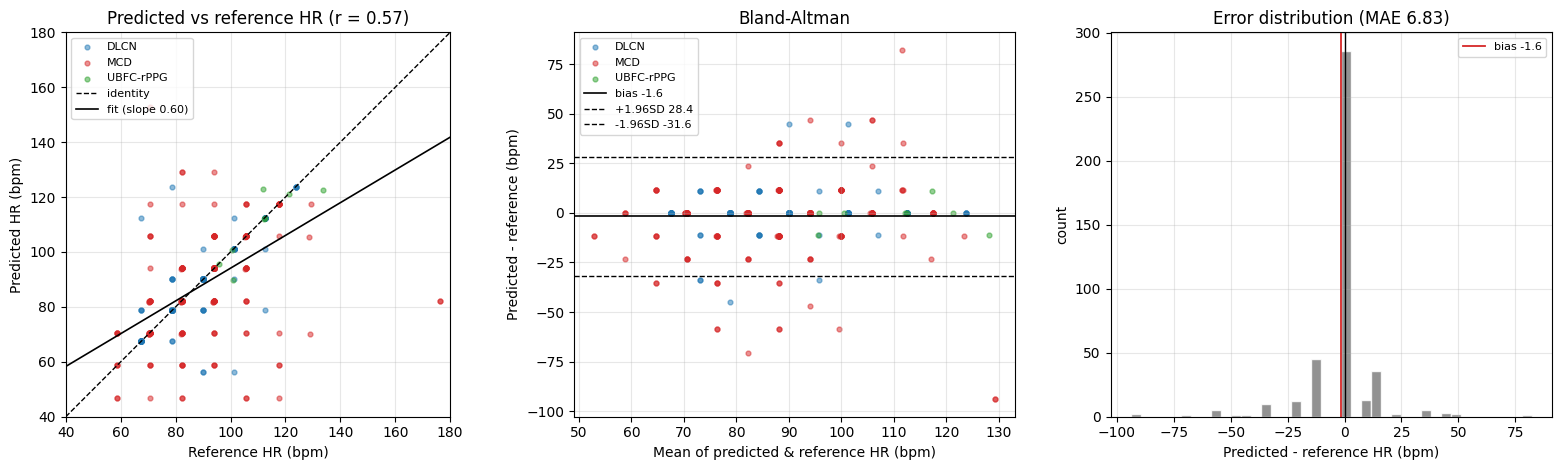

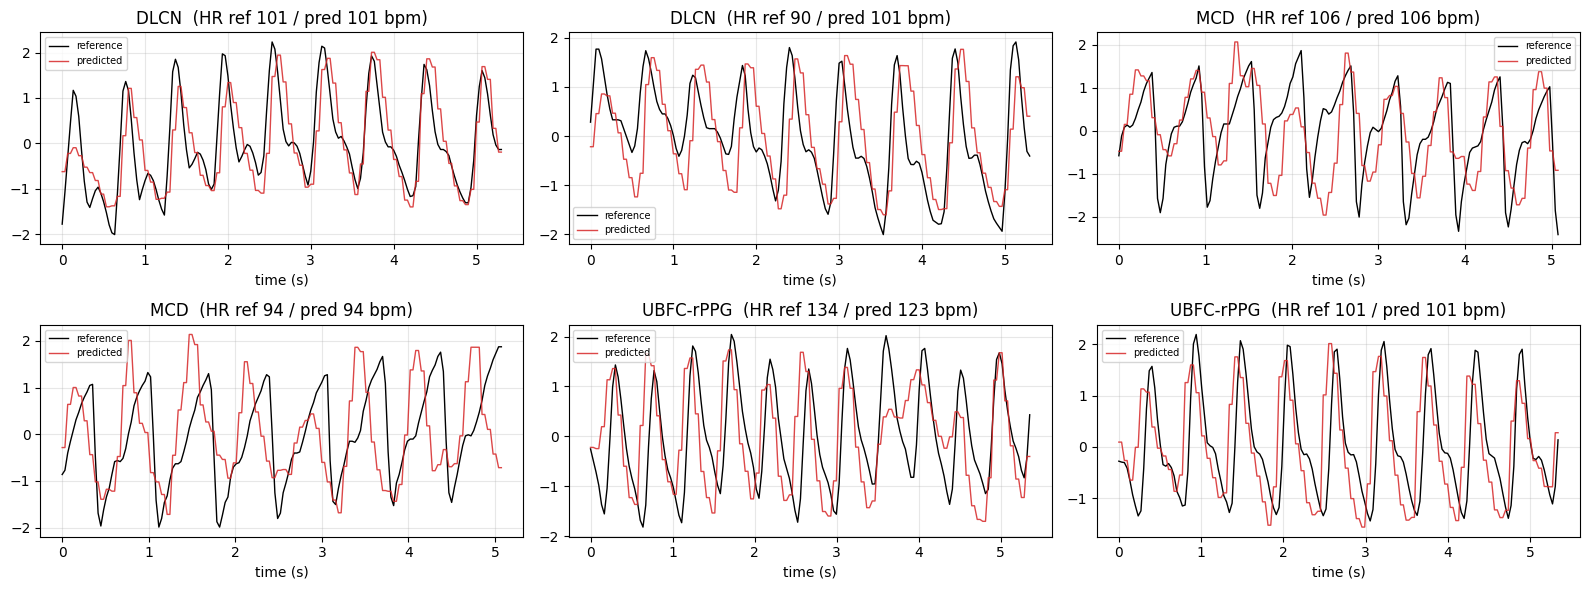

In [7]:
model.load_state_dict(torch.load('rhythmmamba_best.pt', map_location=device))
model.eval()

@torch.no_grad()
def collect_predictions(model, loader, waves_per_ds=2):
    rows, waves, wave_ct = [], [], {}
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = rm_forward(model, frames)
        pred = pred.float().cpu().numpy(); bvp = batch['bvp'].numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if not np.isfinite(hp):
                continue
            rows.append((ds[i], float(hr_true[i]), hp))
            if wave_ct.get(ds[i], 0) < waves_per_ds:
                waves.append((ds[i], float(fps[i]), bvp[i].copy(), pred[i].copy()))
                wave_ct[ds[i]] = wave_ct.get(ds[i], 0) + 1
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred']), waves

pred_df, wave_examples = collect_predictions(model, val_loader)
print('eval clips:', len(pred_df))


def metrics_block(g):
    d = (g['hr_pred'] - g['hr_true']).values
    sd = d.std(ddof=1) if len(d) > 1 else np.nan
    return pd.Series({'n': len(g), 'MAE': np.abs(d).mean(), 'RMSE': np.sqrt((d ** 2).mean()),
                     'bias': d.mean(), 'SD': sd, 'LoA_low': d.mean() - 1.96 * sd,
                     'LoA_high': d.mean() + 1.96 * sd,
                     'Pearson_r': np.corrcoef(g['hr_true'], g['hr_pred'])[0, 1] if len(g) > 2 else np.nan})

summary = pred_df.groupby('dataset').apply(metrics_block, include_groups=False)
overall = metrics_block(pred_df); overall.name = 'ALL'
print(pd.concat([summary, overall.to_frame().T]).round(2).to_string())

colors = {'MCD': 'tab:red', 'DLCN': 'tab:blue', 'UBFC-rPPG': 'tab:green'}
diff = (pred_df.hr_pred - pred_df.hr_true).values
bias, sd = diff.mean(), diff.std(ddof=1)
r = np.corrcoef(pred_df.hr_true, pred_df.hr_pred)[0, 1]
lim = [40, 180]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
for ds, gdf in pred_df.groupby('dataset'):
    ax[0].scatter(gdf.hr_true, gdf.hr_pred, s=12, alpha=0.5, color=colors.get(ds, 'gray'), label=ds)
ax[0].plot(lim, lim, 'k--', lw=1, label='identity')
slope, intc = np.polyfit(pred_df.hr_true, pred_df.hr_pred, 1)
ax[0].plot(np.array(lim), intc + slope * np.array(lim), 'k-', lw=1.2, label=f'fit (slope {slope:.2f})')
ax[0].set(xlim=lim, ylim=lim, xlabel='Reference HR (bpm)', ylabel='Predicted HR (bpm)',
          title=f'Predicted vs reference HR (r = {r:.2f})', aspect='equal')
ax[0].legend(fontsize=8, loc='upper left'); ax[0].grid(alpha=0.3)
for ds, gdf in pred_df.groupby('dataset'):
    m = (gdf.hr_true + gdf.hr_pred) / 2; d = gdf.hr_pred - gdf.hr_true
    ax[1].scatter(m, d, s=12, alpha=0.5, color=colors.get(ds, 'gray'), label=ds)
ax[1].axhline(bias, color='k', lw=1.2, label=f'bias {bias:.1f}')
ax[1].axhline(bias + 1.96 * sd, color='k', ls='--', lw=1, label=f'+1.96SD {bias + 1.96 * sd:.1f}')
ax[1].axhline(bias - 1.96 * sd, color='k', ls='--', lw=1, label=f'-1.96SD {bias - 1.96 * sd:.1f}')
ax[1].set(xlabel='Mean of predicted & reference HR (bpm)', ylabel='Predicted - reference (bpm)', title='Bland-Altman')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[2].hist(diff, bins=40, color='tab:gray', alpha=0.85, edgecolor='white')
ax[2].axvline(0, color='k', lw=1); ax[2].axvline(bias, color='tab:red', lw=1.3, label=f'bias {bias:.1f}')
ax[2].set(xlabel='Predicted - reference HR (bpm)', ylabel='count',
          title=f'Error distribution (MAE {np.abs(diff).mean():.2f})')
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
for k, (ds, fps, bt, bp) in enumerate(wave_examples[:6]):
    axr = axes[k // 3, k % 3]
    bt = (bt - bt.mean()) / (bt.std() + 1e-6); bp = (bp - bp.mean()) / (bp.std() + 1e-6)
    t = np.arange(len(bt)) / fps
    axr.plot(t, bt, color='k', lw=1.0, label='reference')
    axr.plot(t, bp, color='tab:red', lw=1.0, alpha=0.85, label='predicted')
    axr.set(title=f'{ds}  (HR ref {hr_from_bvp(bt, fps):.0f} / pred {hr_from_bvp(bp, fps):.0f} bpm)', xlabel='time (s)')
    axr.legend(fontsize=7); axr.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
def clip_sqi(bvp, fps, low=0.7, high=3.5):
    '''3-bin peak-power fraction of the reference BVP = how trustworthy this clip's true-HR label is.'''
    x = np.asarray(bvp, float); x = x - x.mean()
    if x.std() < 1e-8:
        return 0.0
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return 0.0
    pk = int(np.argmax(p[b]))
    return float(p[b][max(0, pk - 1):pk + 2].sum() / p[b].sum())

FWD = lambda f: rm_forward(model, f)

@torch.no_grad()
def collect_with_sqi(model, loader, fwd):
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = fwd(frames)
        pred = pred.float().cpu().numpy()
        bvp = batch['bvp'].numpy(); hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if not np.isfinite(hp):
                continue
            rows.append((ds[i], float(hr_true[i]), hp, clip_sqi(bvp[i], float(fps[i]))))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred', 'ref_sqi'])

df = collect_with_sqi(model, val_loader, FWD)
df['ae'] = (df.hr_pred - df.hr_true).abs()
print('total eval clips:', len(df))
for thr in [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]:
    sub = df[df.ref_sqi >= thr]
    if len(sub) < 5:
        continue
    r = np.corrcoef(sub.hr_true, sub.hr_pred)[0, 1] if len(sub) > 2 else float('nan')
    pds = sub.groupby('dataset')['ae'].mean().round(2).to_dict()
    print(f'ref_sqi>={thr:.2f} | n {len(sub):4d} | MAE {sub.ae.mean():5.2f} | r {r:.3f} | per-dataset {pds}')

total eval clips: 425
ref_sqi>=0.00 | n  425 | MAE  6.83 | r 0.569 | per-dataset {'DLCN': 2.32, 'MCD': 10.49, 'UBFC-rPPG': 4.19}
ref_sqi>=0.05 | n  425 | MAE  6.83 | r 0.569 | per-dataset {'DLCN': 2.32, 'MCD': 10.49, 'UBFC-rPPG': 4.19}
ref_sqi>=0.10 | n  425 | MAE  6.83 | r 0.569 | per-dataset {'DLCN': 2.32, 'MCD': 10.49, 'UBFC-rPPG': 4.19}
ref_sqi>=0.15 | n  425 | MAE  6.83 | r 0.569 | per-dataset {'DLCN': 2.32, 'MCD': 10.49, 'UBFC-rPPG': 4.19}
ref_sqi>=0.20 | n  425 | MAE  6.83 | r 0.569 | per-dataset {'DLCN': 2.32, 'MCD': 10.49, 'UBFC-rPPG': 4.19}
ref_sqi>=0.30 | n  425 | MAE  6.83 | r 0.569 | per-dataset {'DLCN': 2.32, 'MCD': 10.49, 'UBFC-rPPG': 4.19}
